# Import Required Libraries
Import pandas for data handling and matplotlib.pyplot and seaborn for plotting.

In [19]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting for Jupyter
%matplotlib inline

# Load CSV File
Use pandas to read the CSV file into a DataFrame. You can change the file path below to your CSV file.

In [20]:
# Load CSV File
csv_path = '/home/daniele/Desktop/tirocinio/energyBANERA-main/Data/Jetson_nano_power_record/Linear/Linear_64_64.csv'  # Change this to your CSV file path
df = pd.read_csv(csv_path)

# Display Data Overview
Show the first few rows and basic info about the DataFrame to understand its structure.

In [21]:
# Display Data Overview
display(df.head())
df.info()
df.describe()

,Sample,EVM1 VSHUNT Results (mV),EVM1 VBUS Results (V),EVM1 CURRENT Results (A),EVM1 POWER Results (W)
0,0,0.7375,5.20625,0.076910,0.400572
1,1,0.9450,5.17625,0.078741,0.409728
2,2,0.7400,5.19125,0.061711,0.318169
3,3,0.7675,5.19750,0.074163,0.386838
4,4,0.8025,5.18125,0.066838,0.345637


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sample                    10000 non-null  int64  
 1   EVM1 VSHUNT Results (mV)  10000 non-null  float64
 2   EVM1 VBUS Results (V)     10000 non-null  float64
 3   EVM1 CURRENT Results (A)  10000 non-null  float64
 4   EVM1 POWER Results (W)    10000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


,Sample,EVM1 VSHUNT Results (mV),EVM1 VBUS Results (V),EVM1 CURRENT Results (A),EVM1 POWER Results (W)
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,1.019733,5.185538,0.084963,0.439197
std,2886.89568,0.528195,0.033215,0.044134,0.223521
min,0.00000,0.675000,5.057500,0.056217,0.292990
25%,2499.75000,0.747500,5.182500,0.062260,0.322747
50%,4999.50000,0.827500,5.195000,0.068761,0.357082
75%,7499.25000,0.895000,5.208750,0.074804,0.389127
max,9999.00000,3.135000,5.218750,0.268361,1.357368


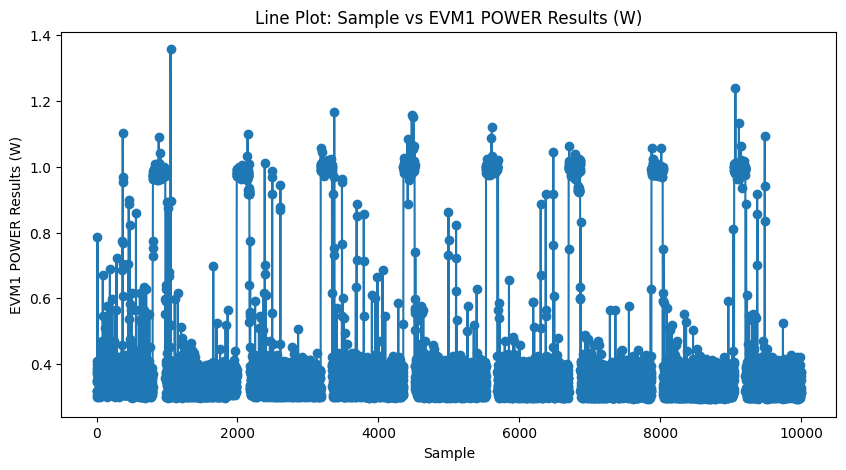

In [22]:
# Line plot: sample index (abscissa) vs 'EVM1 POWER Results' (ordinate)

plt.figure(figsize=(10, 5))
plt.plot(df['Sample'], df['EVM1 POWER Results (W)'], marker='o')
plt.xlabel('Sample')
plt.ylabel('EVM1 POWER Results (W)')
plt.title(f'Line Plot: Sample vs EVM1 POWER Results (W)')
plt.show()


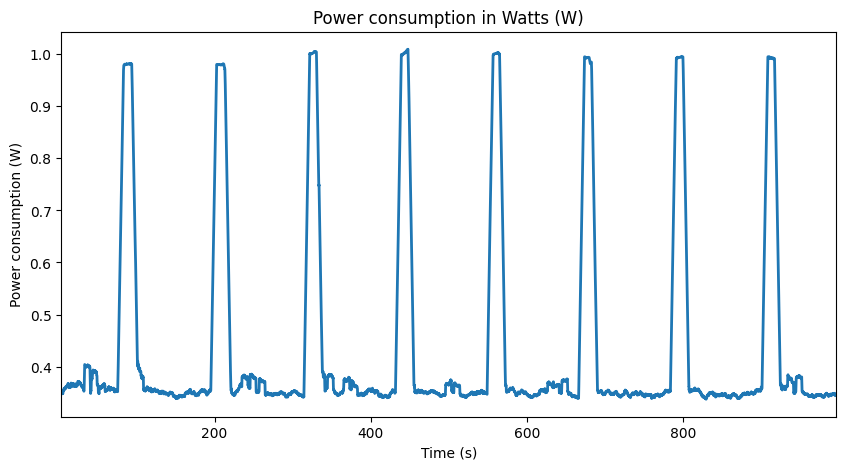

In [25]:
# Smooth the 'EVM1 POWER Results (W)' using a rolling mean
window_size = 75  # Adjust the window size as needed
smoothed = df['EVM1 POWER Results (W)'].rolling(window=window_size, center=True).mean()

smoothed = smoothed.dropna()
# Align 'Sample' values with the smoothed data index
sample_aligned = df['Sample'].iloc[smoothed.index]

time_sec = df['Sample'] * 0.1 # Assuming each sample corresponds to 0.1 seconds
#time_sec = df['Sample'] / 1000 # Assuming 'Sample' is in milliseconds, convert to seconds
time_sec_smoothed = time_sec.iloc[smoothed.index]

plt.figure(figsize=(10, 5))
plt.plot(time_sec_smoothed, smoothed, label=f'Rolling Mean (window={window_size})',linewidth=2.0)
plt.xlim(time_sec_smoothed.min(), time_sec_smoothed.max())
plt.xlabel('Time (s)')
plt.ylabel('Power consumption (W)')
plt.title('Power consumption in Watts (W)')
#plt.legend()
#plt.savefig("high_res_plot.svg",format='svg', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

